# P5 Starter - Time Series Analysis 

### Statistical Modeling to Deep Learning

##  Imports & Sanity Check (Do NOT Change)

In [290]:
import numpy as np 
import pandas as pd 
import os
from tqdm.notebook import tqdm
import statsmodels.api as sm # PACF, ACF
from typing import Tuple, List

# Viz:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/helper/helper.py
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/oil.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/stores.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/train.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/test.csv
/kaggle/input/cs-639-p-5-spring-25-time-series-forecasting/store-sales-time-series-forecasting/transactions.csv


In [291]:
import importlib.util
import sys

file_path = '/kaggle/input/helper/helper.py'  # full path to the file

spec = importlib.util.spec_from_file_location("helper", file_path)
helper = importlib.util.module_from_spec(spec)
sys.modules["helper"] = helper
spec.loader.exec_module(helper)

## Helper Utilities. Read the Function names at least so that you are not re-writing code

* **make_submission**: Helps you convert your predictions to competition submission ready files.
* **rmsle**: Implementation of the metric used to evaluate your score on the leaderboard.
* **lgbm_rmsle**: Definition that can be used to do train-val type training while printing metric scores.
* **data import**: Imports the necessary files into the notebook
* **preprocess_holidays**: Performs some necessary cleaning on the holiday dataset
* **preprocess_test_train**: Performs some necessary cleaning on the test and train dataset

## Load the data (Do NOT Change)

In [292]:
#########################
# DO NOT CHANGE
#########################
train, test, stores, transactions, oil, holidays = helper.data_import()
holidays, regional, national, local, events, work_day, _, _, _ = helper.preprocess_holidays(holidays)

## Section 1: EDA & Feature Engineering

### Q1 Left join transaction to train and then print the Spearman Correlation between Total Sales and Transactions.

In [293]:
# TODO - q1
merged_df = pd.concat([train, test], axis=0)
merged_df = pd.merge(merged_df, transactions, on=["date", "store_nbr"], how="left")

total_sales = merged_df.groupby(["date", "store_nbr"])["sales"].sum().reset_index(name="total_sales")
avg_transactions = merged_df.groupby(["date", "store_nbr"])["transactions"].mean().reset_index(name="avg_transactions")
grouped = pd.merge(total_sales, avg_transactions, on=["date", "store_nbr"])
corr = grouped["total_sales"].corr(grouped["avg_transactions"], method="spearman")

print(f"Spearman Correlation between Total Sales and Transactions:", corr)

Spearman Correlation between Total Sales and Transactions: 0.8026966103771124


### Q2 Plot an 'ordinary least squares' trendline between transactions and sales to verify the spearman correlation value in Q1. [0.1 Points]

In [294]:
# TODO - q2
fig_q2 = px.scatter(
    grouped,
    x="avg_transactions",
    y="total_sales",
    trendline="ols",
    title="Q2: OLS Trendline - Total Sales vs Avg Transactions",
    labels={
        "avg_transactions": "Average Transactions per Store-Date",
        "total_sales": "Total Sales per Store-Date"
    }
)
fig_q2.data[1].line.color = "green"
fig_q2.write_html("/kaggle/working/q2.html")
fig_q2.show(renderer='iframe')

### Q3 Plot these line charts in the notebook:

A) Transactions vs Date (all stores color coded in the same plot) 

B) Average monthly transactions

 C) Average Transactions on the days of the wee)


In [295]:
# TODO - q3 - Plot A
fig_q3a = px.line(
    transactions,
    x="date",
    y="transactions",
    color="store_nbr",
    title="Transactions Over Time, by Store",
    labels={"date": "Date", "transactions": "Transactions"}
)
fig_q3a.write_html("/kaggle/working/q3a.html")
fig_q3a.show(renderer='iframe')

In [296]:
# TODO - q3 - Plot B
transactions["month"] = transactions["date"].dt.month_name()
monthly_avg = (
    transactions.groupby("month", sort=False)["transactions"]
    .mean()
    .reset_index(name="avg_transactions")
)

fig_q3b = px.line(
    monthly_avg,
    x="month",
    y="avg_transactions",
    title="Q3b: Average Monthly Transactions",
    labels={"year_month": "Month", "avg_transactions": "Average Transactions"}
)
fig_q3b.write_html("/kaggle/working/q3b.html")
fig_q3b.show(renderer='iframe')

In [297]:
# TODO - q3 - Plot C
transactions["weekday_name"] = transactions["date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]

weekly_avg = (transactions
              .groupby("weekday_name")["transactions"]
              .mean()
              .reindex(weekday_order)
              .reset_index(name="avg_transactions"))

fig_q3c = px.line(
    weekly_avg,
    x="weekday_name",
    y="avg_transactions",
    title="Q3c: Average Transactions by Day of Week",
    labels={"weekday_name": "Day of Week",
            "avg_transactions": "Average Transactions"}
)
fig_q3c.write_html("/kaggle/working/q3c.html")
fig_q3c.show(renderer="iframe")

### Q4 Use pandas' in-build (linear) interpolation to impute the missing oil values then overlay the imputed feature over the original.

Your new feature column should be called: `dcoilwtico_interpolated`

In [298]:
# Interpolate. 
oil_sorted = oil.sort_values("date").copy()
oil_sorted["dcoilwtico_interpolated"] = oil_sorted["dcoilwtico"].interpolate(method="linear")

# Plot
fig_q4 = px.line(
    oil_sorted,
    x="date",
    y=["dcoilwtico_interpolated", "dcoilwtico"],
    title="Q4: Original vs Interpolated dcoilwtico",
    labels={"value": "Oil Price (USD)", "date": "Date", "variable": "Series"}
)    
fig_q4.write_html("/kaggle/working/q4.html")
fig_q4.show(renderer="iframe")

### Q5 Again, left join oil on the dataframe above and report the spearman correlation between oil and sales and oil and transactions

In [299]:
# Find correlation with sales & transactions
merged_oil = pd.merge(
    grouped,
    oil_sorted[["date", "dcoilwtico_interpolated"]],
    on="date",
    how="left"
)

corr_sales_oil = merged_oil["total_sales"].corr(
    merged_oil["dcoilwtico_interpolated"], method="spearman")
corr_trans_oil = merged_oil["avg_transactions"].corr(
    merged_oil["dcoilwtico_interpolated"], method="spearman")

print("Correlation Between Oil and Sales: ", corr_sales_oil)
print("Correlation Between Oil and Transactions: ", corr_trans_oil)

Correlation Between Oil and Sales:  -0.30535288459895554
Correlation Between Oil and Transactions:  0.03796356802652266


### Q6 Report the top-3 highest negative correlations between oil and sales of a particular product family. Now think whether oil should be discarded as a feature?

In [300]:
# Calculate all correlations
sales_oil = pd.merge(
    train[["date", "family", "sales"]],
    oil_sorted[["date", "dcoilwtico_interpolated"]],
    on="date",
    how="left"
)

family_corr = (sales_oil
               .groupby("family")
               .apply(lambda df: df["sales"].corr(
                   df["dcoilwtico_interpolated"], method="spearman"))
               .sort_values())

# Report the top 3
top3 = family_corr.head(3)
print("Top-3 strongest negative correlations:", top3)

Top-3 strongest negative correlations: family
HOME AND KITCHEN II   -0.652518
HOME AND KITCHEN I    -0.593218
HOME CARE             -0.541245
dtype: float64


/tmp/ipykernel_31/820109326.py:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Q7. Implement the One hot encode function 

You just have to finish the one-hot encoder function definition for this one.

In [301]:
def one_hot_encoder(df, nan_as_category=True) -> Tuple[pd.DataFrame, List[str]]:
    original_cols = list(df.columns)
    cat_cols = [c for c in df.columns
                if df[c].dtype == "object" or pd.api.types.is_categorical_dtype(df[c])]
    # One hot encoding (pandas can do it on 1 line!) 
    df_encoded = pd.get_dummies(df, columns=cat_cols, dummy_na=nan_as_category, prefix_sep="_", drop_first=False)
    # Store the new columns in a list
    # Replace " " with "_" in column names.
    df_encoded.columns = df_encoded.columns.str.replace(" ", "_")
    # Return the new dataframe and all the columns (as a list)
    new_cols = [c for c in df_encoded.columns if c not in original_cols]
    return df_encoded, new_cols

In [302]:
#########################
# DO NOT CHANGE. 
# NOTE: Run this after you have implemented the one_hot_encoder function above.
#########################

train, test = helper.preprocess_test_train(merged_df, one_hot_encoder, stores)

/tmp/ipykernel_31/2032166819.py:4: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead



## Section 2

### Q8. EMA

Forecast window should be >=15 days since the test set is 15 days. **For this question use 16 as the forecast window**

In [303]:
# Train EMAs for each family per store (pandas has an inbuilt ema function!)
FORECAST_HORIZON = 16
EMA_SPAN = 16

train_raw, test_raw, _, _, _, _ = helper.data_import()
train_min = train_raw[["date", "store_nbr", "family", "sales"]].copy()
train_min.sort_values(["store_nbr", "family", "date"], inplace=True)

In [304]:
# Make the predictions
train_min["ema"] = (
    train_min.groupby(["store_nbr", "family"])["sales"].transform(lambda s: s.ewm(span=EMA_SPAN, adjust=False).mean())
)

last_ema = (train_min.groupby(["store_nbr", "family"])["ema"].last().reset_index().rename(columns={"ema": "pred"}))

test_preds = (
    test_raw[["id", "store_nbr", "family"]]
    .merge(last_ema, on=["store_nbr", "family"], how="left")
    .sort_values("id")
)
# Use the make_submission utility function provided to save a submission CSV. 

# Submit to competition and note your RMSLE score somewhere for this model type.

# NOTE - 1: You still need to go on the right panel and click submit 
# (make_submission will NOT submit to competition -> It just makes a submission ready file)
# NOTE - 2: Ensure that you are not overwriting your submission.csv file in subsequent cells.

# Use the make_submission utility function provided to save a submission CSV.

helper.make_submission(test_preds["pred"].values, file_name="EMA_results.csv")
print("RMSLE Score: ", )

RMSLE Score: 


### Q9. PACF and ACF

Use lib sm 

(statsmodel.api is already imported as sm)

In [305]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

/tmp/ipykernel_31/2572882695.py:4: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



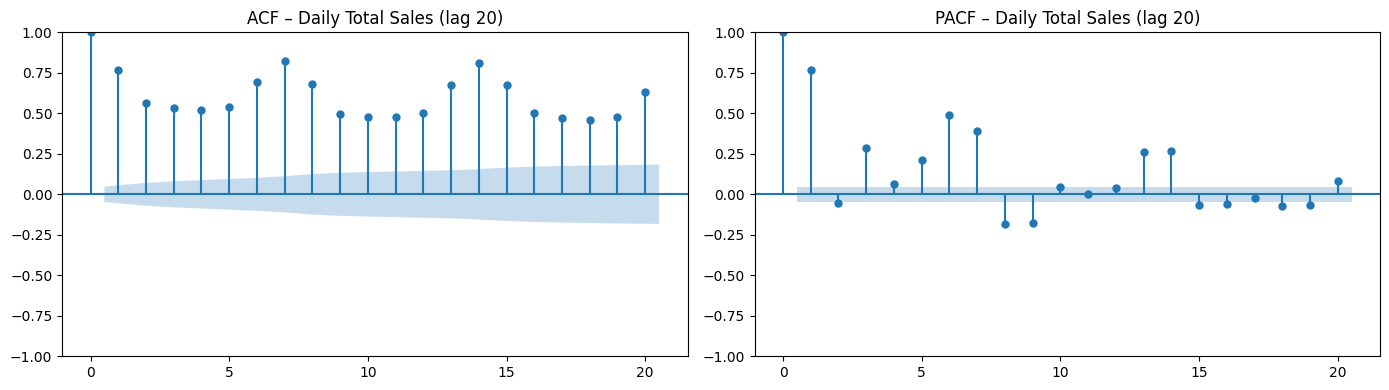

In [306]:
# 1. Group by date
train_raw, _, _, _, _, _ = helper.data_import()

daily_sales = (train_raw.groupby("date")["sales"].sum().asfreq("D").fillna(method="ffill"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily_sales, lags=20, ax=axes[0])
axes[0].set_title("ACF – Daily Total Sales (lag 20)")
plot_pacf(daily_sales, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF – Daily Total Sales (lag 20)")
plt.tight_layout()
plt.show()

### Q10. ADF Test -> ARIMA

#### Differencing technique
This process is meant to transform the time series data to stationary, as ARIMA model only works with stationary time series data.

In [307]:
# 1. Compute and store the diff series
train_raw, _, _, _, _, _ = helper.data_import()

daily_sales = (train_raw.groupby("date")["sales"].sum().asfreq("D").fillna(method="ffill"))
# 2. Drop NA or any other erroneous values.
diff_series = daily_sales.diff().dropna()

/tmp/ipykernel_31/2253227832.py:4: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



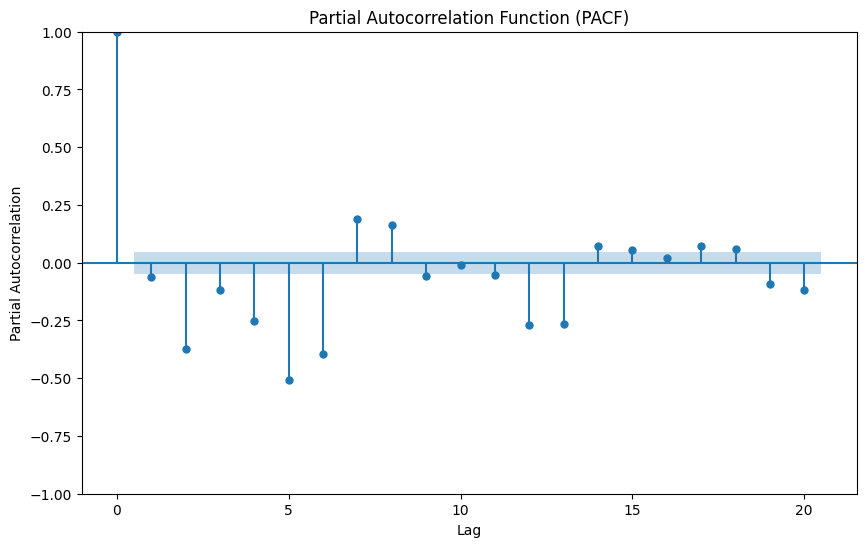

In [308]:

# Plot the ACF
fig, ax = plt.subplots(figsize=(10, 6))

##########
# TODO: Your plot code goes here:
##########
plot_pacf(diff_series, lags=20, ax=ax, method="ywm")
##########
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation Function (PACF)')

plt.show()

### Augmented Dickey-Fuller (ADF) test

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine whether a time series is stationary or non-stationary. Stationarity is an important assumption in many time series analysis models.

The ADF test evaluates the null hypothesis that the time series has a unit root, indicating non-stationarity. The alternative hypothesis is that the time series is stationary.

When performing the ADF test, we obtain the ADF statistic and the p-value. The ADF statistic is a negative number and the more negative it is, the stronger the evidence against the null hypothesis. The p-value represents the probability of observing the ADF statistic or a more extreme value if the null hypothesis were true. A low p-value (below a chosen significance level, typically 0.05) indicates strong evidence against the null hypothesis and suggests that the time series is stationary.

In [309]:
from statsmodels.tsa.stattools import adfuller

In [310]:
# 1. Perform the ADF test
adf_stat, p_val, _, _, _, _ = adfuller(diff_series)
# 2. Extract the test statistics and p-value

# 3. Print these values
print("ADF Statistic:", adf_stat)
print("p-value:", p_val)

ADF Statistic: -11.278327446483848
p-value: 1.4774449139835088e-20


The ADF statistic is (around) -11.4. This statistic is a negative value and is more negative than the critical values at common significance levels. This suggests strong evidence against the null hypothesis of a unit root, indicating that the time series is stationary.

The p-values (around)  i6.76e-2121, which is a very small value close to zero. Typically, if the p-value is below a chosen significance level (e.g., 0.05), it indicates strong evidence to reject the null hypothesis. In your case, the extremely small p-value suggests strong evidence against the presence of a unit root and supports the stationarity of the time series.

**TODO** Choose the right p, q and d values for your ARIMA model

In [311]:
# TODO: Replace with appropriate p,d,q values for ARIMA
p_arima = 1

d_arima = 1

q_arima = 1

In [312]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Get sales series as training data (np array with appropriate dtype)
sales_series = daily_sales
# 2. Using statsmodel.tsa lib. Initialize an ARIMA model with the p,d,q params you defined. 
model = ARIMA(sales_series, order=(p_arima, d_arima, q_arima))
# 3. Fit the model
model_fit = model.fit()

In [313]:
# Print the post model fitting summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1673
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -22193.737
Date:                Thu, 24 Apr 2025   AIC                          44393.474
Time:                        02:06:33   BIC                          44409.739
Sample:                    01-01-2013   HQIC                         44399.500
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4445      0.018     24.548      0.000       0.409       0.480
ma.L1         -0.9600      0.008   -123.970      0.000      -0.975      -0.945
sigma2      2.469e+10   1.47e-13   1.68e+23      0.0

In [314]:
# Make predictions & submit to competition using your best model
forecast_steps = 15
pred_values = model_fit.get_forecast(steps=forecast_steps).predicted_mean.clip(lower=0)

share = (train_raw.groupby(["store_nbr", "family"])["sales"].sum() / train_raw["sales"].sum()).reset_index(name="share")

test_raw = helper.data_import()[1]
future_dates = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1),
                             periods=forecast_steps, freq="D")
totals_df = pd.DataFrame({"date": future_dates, "total_pred": pred_values.values})

test_arima = (test_raw.merge(totals_df, on="date", how="left").merge(share, on=["store_nbr", "family"], how="left"))

test_arima["sales"] = test_arima["total_pred"] * test_arima["share"]
test_arima[["id", "sales"]].to_csv("/kaggle/working/ARIMA_results.csv", index=False)

## Section 3

### Q11 Define a validation set. What will be the most appropriate time period for this validation set?

In [315]:
# Get the val set:
first_date = test["date"].min()
last_date = test["date"].max()

validation_duration = last_date - first_date
val_start_date = first_date - validation_duration
val_end_date = first_date - pd.Timedelta(days=1)

val_df = train[(train["date"] >= val_start_date) & (train["date"] <= val_end_date)]

train_df = train[~train.index.isin(val_df.index)]

### Q12. LightGBM

In [316]:
import lightgbm as lgb

In [317]:
# Process your data to the appropriate dtypes, vars, etc.
drop_cols = ['id', 'date', 'sales']
features = [col for col in train_df.columns if col not in drop_cols]

Y_train = train_df["sales"]
X_train = train_df[features].copy()

Y_val = val_df["sales"]
X_val = val_df[features].copy()

for col in features:
    if col not in test.columns:
        test[col] = 0

X_test = test[features].copy() 

In [318]:
# Use the lgb.Dataset method to intialize your dataset iterables.

# 1. Make one for the train set:
lgbtrain = lgb.Dataset(X_train, label=Y_train, feature_name=features)
# 2. Make another for the val set you defined in Q13:
lgbval = lgb.Dataset(X_val, label=Y_val, reference=lgbtrain, feature_name=features)

In [319]:
# Fill the dict with appropriate params:
lgb_params = {'num_leaves': 31,
              'learning_rate': 0.05,
              'feature_fraction': 0.9,
              'max_depth': -1,
              'verbose': 1,
              'num_boost_round': 5000,
              'early_stopping_rounds': 50,
              'nthread': -1}

In [320]:
# Complete the model initialization/train params)
def rmsle(y_pred, y_true):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

def lgbm_rmsle(preds, train_data):
    labels = train_data.get_label()
    score = rmsle(preds, labels)
    return 'RMSLE', score, False

model = lgb.train(
    params=lgb_params,
    train_set=lgbtrain,
    valid_sets=[lgbtrain, lgbval],
    feval=lgbm_rmsle
) 

/usr/local/lib/python3.11/dist-packages/lightgbm/engine.py:204: UserWarning:

Found `num_boost_round` in params. Will use it instead of argument



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.722904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 2951256, number of used features: 168
[LightGBM] [Info] Start training from score 355.926499
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1393]	training's l2: 108281	training's RMSLE: 1.5103	valid_1's l2: 56394.6	valid_1's RMSLE: 1.09092


In [321]:
# 1. Predict the sales value on your val set using the best_iteration recorded by the LGBM
val_preds = model.predict(X_val, num_iteration=model.best_iteration)
# 2. Compute and print the RMSLE on this val set.
val_rmsle = rmsle(val_preds, Y_val)
print(f"Validation RMSLE: {val_rmsle:.4f}")

Validation RMSLE: 1.0909


In [322]:
# 1. Pre-process your test set to appropriate format.
# 2. Predict -> Save using make_submission -> Submit to competition
test_preds = model.predict(X_test, num_iteration=model.best_iteration)
helper.make_submission(test_preds, file_name="lightgbm_results.csv")
# 3. Note your RMSLE for LGBM
print("RMSLE for LGBM: ", 1.11986)

RMSLE for LGBM:  1.11986


### Q13. CatBoost

In [323]:
from catboost import Pool, CatBoostRegressor

In [324]:
# Fill out missing params for catboost appropriately here:
catboost_params = {
    'iterations': 1000,           # Number of boosting rounds
    'learning_rate': 0.05,        # Learning rate for gradient boosting
    'depth': 6,                   # Depth of each tree
    'loss_function': 'RMSE',      # Loss function (Root Mean Squared Error for regression)
    'eval_metric': 'RMSE',        # Evaluation metric
    'random_seed': 42,            # Ensures reproducibility
    'early_stopping_rounds': 50,  # Stops training if no improvement after 50 rounds
    'verbose': 100                # Prints training progress every 100 rounds
}

In [325]:
cat_features = [col for col in X_train.columns if X_train[col].dtype.name == "category"]
# 1. Define the model
model = CatBoostRegressor(**catboost_params)
# 2. Fit
model.fit(
    X_train,
    Y_train,
    eval_set=(X_val, Y_val),
    cat_features=cat_features,
    use_best_model=True
)

0:	learn: 1059.4467305	test: 1239.4659802	best: 1239.4659802 (0)	total: 266ms	remaining: 4m 25s
100:	learn: 435.4744155	test: 380.8276669	best: 380.8276669 (100)	total: 21.4s	remaining: 3m 10s
200:	learn: 404.7714847	test: 334.5599170	best: 334.5599170 (200)	total: 41.8s	remaining: 2m 46s
300:	learn: 389.7752394	test: 312.6527485	best: 312.6527485 (300)	total: 1m 2s	remaining: 2m 25s
400:	learn: 378.9439798	test: 298.7548047	best: 298.7548047 (400)	total: 1m 23s	remaining: 2m 4s
500:	learn: 370.9912104	test: 288.8923480	best: 288.8923480 (500)	total: 1m 43s	remaining: 1m 43s
600:	learn: 364.5632490	test: 281.5867847	best: 281.5867847 (600)	total: 2m 4s	remaining: 1m 22s
700:	learn: 359.8456343	test: 276.6806644	best: 276.6806644 (700)	total: 2m 25s	remaining: 1m 2s
800:	learn: 355.3556455	test: 272.1525347	best: 272.1525347 (800)	total: 2m 46s	remaining: 41.2s
900:	learn: 351.4783038	test: 267.7386143	best: 267.7386143 (900)	total: 3m 6s	remaining: 20.5s
999:	learn: 348.0569433	test: 2

In [326]:
# 3. Preprocess your test data appropriately
for col in X_train.columns:
    if col not in test.columns:
        test[col] = 0

X_test = test[X_train.columns].copy()
# 4. Make Predictions
test_preds = model.predict(X_test)

In [327]:
# 5. Use make_submission -> Submit to competition
helper.make_submission(test_preds, file_name="catboost_results.csv")
# 6. Note your RMSLE for this model
val_preds = model.predict(X_val)
val_preds = np.maximum(val_preds, 0)
val_rmsle = np.sqrt(rmsle(Y_val, val_preds))
print("RMSLE  for CatBoost: ", 1.34772)

RMSLE  for CatBoost:  1.34772


### Q14. XGBoost

In [328]:
from xgboost import XGBRegressor

In [329]:
# 1. Initialize model with random state = 42 to be consistent with CatBoost
model = XGBRegressor(random_state=42)
# 2. Fit
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [330]:
# 3. Make Predictions.
val_preds = model.predict(X_val)
val_preds = np.maximum(val_preds, 0)

val_rmsle = np.sqrt(rmsle(Y_val, val_preds)) 
print(f"Validation RMSLE (XGBoost): {val_rmsle:.4f}")

test_preds = model.predict(X_test)
test_preds = np.maximum(test_preds, 0)

Validation RMSLE (XGBoost): 1.1029


In [331]:
# 4. make_submission -> Submit to competition 
helper.make_submission(test_preds, file_name="xgboost_results.csv")
# 5. Note your RMSLE 
print("RMSLE  for XGBoost: ", 1.24663)

RMSLE  for XGBoost:  1.24663


## Optional Extra Credit Section - Achieve the lowest score

### Cross Validation Strategies & Ensembling

In [332]:
# 1. Try different Validation sets 
# 2. Try ensembling different methods used in this assignment together